# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, explore and then clean EPA's PM2.5 monitor dataset.

#### **Scope:** EPA monitor locations and their daily PM2.5 measurements in the United States and its territories for the year 2019.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _daily\_88101\_2019.csv_ | Derived from the U.S. EPA Pre\-Generated Data Files webpage on 10/28/2025, this dataset contains the PM2.5 air monitor data for every day in the year 2019 for all monitors in the United States and its territories;                                                                                                    \-\- Data Dictionary: [https://www.epa.gov/aqs/aqs\-data\-dictionary](https://www.epa.gov/aqs/aqs-data-dictionary) | [https://aqs.epa.gov/aqsweb/airdata/download\_files.html\#Daily](https://aqs.epa.gov/aqsweb/airdata/download_files.html#Daily) \(see "Particulates" and "2019"\) |

#### **Conclusions:** The EPA dataset was cleaned to show unique monitor IDs associated with location data and their daily PM2.5 estimates. PM2.5 estimates are right\-skewed with many outliers, though that distribution isn't unusual for air pollution data. Missingness is only an issue for a variable that will not be included in the final analysis \(i.e., it's being dropped out with this analysis\).



#### General Methodology

##### Steps

1. Download AQS Dataset
2. Load Libraries
3. Load AQS Dataset
4. Explore AQS Dataset
5. Select Relevant AQS Dataset Variables
6. Generate a Dataset of PM2.5 Monitors with Locations

##### Pseudocode

1. Load libraries I will likely need
2. Load AQS dataset: DF &lt;\- read.csv
3. Limited\_DF &lt;\- Select\(State.Code, County.Code, Site.Num, Latitude, Longitude, Address, [State.Name](http://State.Name), [County.Name](http://County.Name), [City.Name](http://City.Name)\)
4. Unique identifier \(AQS\_ID\) &lt;\- Leading\_Zeros\_If\_Needed\(State.Code \+ County.Code  \+ Site.Num\)
5. Filter to unique AQS\_ID w/ locations and daily PM2.5 values



#### Load Libraries



In [3]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(terra)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)


#### Load AQS Dataset



In [4]:
#Purpose of Cell Block: Get dataset

setwd("/home/user/capstone/A_data")
DF_aqs2019 <- read.csv("C_raw_data/air_monitors/daily_88101_2019.csv")

#### Explore AQS Dataset



[1] "The following values are examples of PM2.5 measurements:"


[1] 4.3 8.5 3.3 8.6 9.0 3.7

[1] "The following values are the variables names in the dataset"


[1] "State.Code"          "County.Code"         "Site.Num"           
 [4] "Parameter.Code"      "POC"                 "Latitude"           
 [7] "Longitude"           "Datum"               "Parameter.Name"     
[10] "Sample.Duration"     "Pollutant.Standard"  "Date.Local"         
[13] "Units.of.Measure"    "Event.Type"          "Observation.Count"  
[16] "Observation.Percent" "Arithmetic.Mean"     "X1st.Max.Value"     
[19] "X1st.Max.Hour"       "AQI"                 "Method.Code"        
[22] "Method.Name"         "Local.Site.Name"     "Address"            
[25] "State.Name"          "County.Name"         "City.Name"          
[28] "CBSA.Name"           "Date.of.Last.Change"

Rows: 654,337
Columns: 29
$ State.Code          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ County.Code         <int> 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,…
$ Site.Num            <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ Parameter.Code      <int> 88101, 88101, 88101, 88101, 88101, 88101, 88101, 8…
$ POC                 <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ Latitude            <dbl> 30.49748, 30.49748, 30.49748, 30.49748, 30.49748, …
$ Longitude           <dbl> -87.88026, -87.88026, -87.88026, -87.88026, -87.88…
$ Datum               <chr> "NAD83", "NAD83", "NAD83", "NAD83", "NAD83", "NAD8…
$ Parameter.Name      <chr> "PM2.5 - Local Conditions", "PM2.5 - Local Conditi…
$ Sample.Duration     <chr> "24 HOUR", "24 HOUR", "24 HOUR", "24 HOUR", "24 HO…
$ Pollutant.Standard  <chr> "PM25 24-hour 2012", "PM25 24-hour 2012", "PM25 24…
$ Date.Local          <chr> "2019-01-03", "2019-01-06", "2019-01-09", "2019-01…
$ Units.of.Mea

...

Units.of.Measure,total_distinct
<chr>,<int>
Micrograms/cubic meter (LC),1


[1] "Variables with Missing Data (Percent):"


variable,missing_percent
<chr>,<dbl>
AQI,44.03557


[1] "Shape of Data Assessment: PM2.5"


[1] "Outlier Assessment: PM2.5"


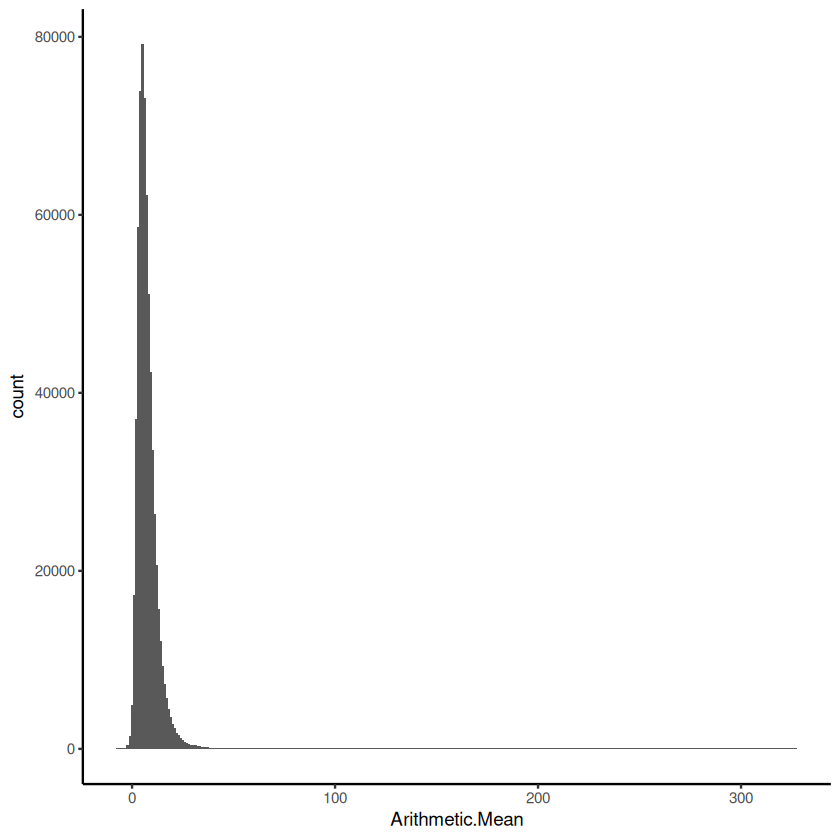

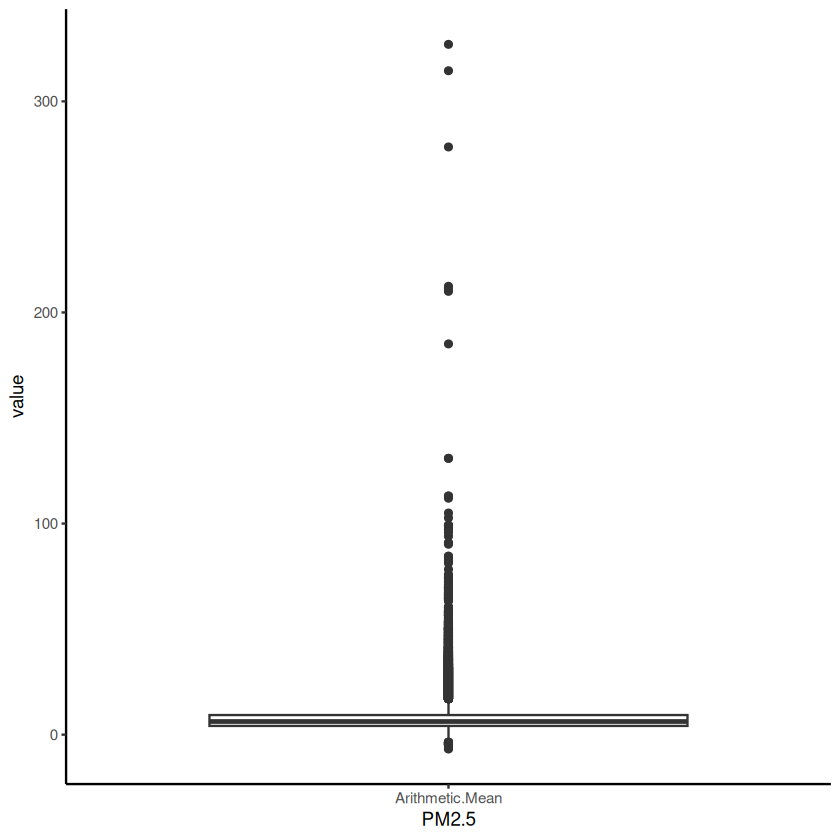

In [5]:
#Purpose of Cell Block: Explore uploaded dataset

print("The following values are examples of PM2.5 measurements:")
head(DF_aqs2019$Arithmetic.Mean)
print("The following values are the variables names in the dataset")
names(DF_aqs2019)
glimpse(DF_aqs2019)
summary(DF_aqs2019)

#Check how many types of units we are dealing with in the dataset
print("Units Used to Measure PM2.5:")
DF_unitcheck <- DF_aqs2019 %>%
    group_by(Units.of.Measure) %>%
    summarise(total_distinct = n_distinct(Units.of.Measure))

DF_unitcheck

#Visualize missingness
print("Variables with Missing Data (Percent):")
DF_aqs2019 %>%
    summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "missing_percent")  %>%
    filter(missing_percent > 0)
  
#describe shape
print("Shape of Data Assessment: PM2.5")
DF_aqs2019 %>%
    ggplot(aes(x=Arithmetic.Mean)) +
    geom_histogram(binwidth = 1) +
    theme_classic()

#Look for outliers
print("Outlier Assessment: PM2.5")
DF_aqs2019 %>%
    pivot_longer(c(Arithmetic.Mean), names_to="PM2.5", values_to="value") %>%
    ggplot(aes(x=PM2.5, y=value)) +
    geom_boxplot() +
    theme_classic()

#Assessment: The dataset is too large. Need to select only the variables of interest. It also appears the AQS ID variables dropped their leading zeros. I will need to fix that issue for a proper unique identifier. PM2.5 is heavily right-skewed with substantial outliers. Right-skew w/ outliers is typical of air pollution data.


#### Select Relevant AQS Dataset Variables



In [7]:
#Purpose of Cell Block: Pulling relevant variables for a smaller dataset

DF_aqs2019_loc <- DF_aqs2019 %>% 
    select('State.Code':'Site.Num','Latitude','Longitude','Address':'City.Name', 'Date.Local', 'Arithmetic.Mean') %>% 
    rename('State_Code' = 'State.Code', 'County_Code' = 'County.Code','State' = 'State.Name', 'Site_Code' = 'Site.Num', 'County' = 'County.Name', 'City' = 'City.Name', 'Date' = 'Date.Local', 'PM25_ugm3' = 'Arithmetic.Mean') %>%
    mutate(Date = as.Date(Date)) #converting date value from character to date

#Confirming new dataset 
head(DF_aqs2019_loc)
dim(DF_aqs2019_loc)
names(DF_aqs2019_loc)
glimpse(DF_aqs2019_loc)
summary(DF_aqs2019_loc)

,State_Code,County_Code,Site_Code,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3
,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>
1,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-03,4.3
2,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-06,8.5
3,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-09,3.3
4,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-12,8.6
5,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-15,9.0
6,1,3,10,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-24,3.7


[1] 654337     11

[1] "State_Code"  "County_Code" "Site_Code"   "Latitude"    "Longitude"  
 [6] "Address"     "State"       "County"      "City"        "Date"       
[11] "PM25_ugm3"

Rows: 654,337
Columns: 11
$ State_Code  <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ County_Code <int> 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3…
$ Site_Code   <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10…
$ Latitude    <dbl> 30.49748, 30.49748, 30.49748, 30.49748, 30.49748, 30.49748…
$ Longitude   <dbl> -87.88026, -87.88026, -87.88026, -87.88026, -87.88026, -87…
$ Address     <chr> "FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE,  ALABAMA"…
$ State       <chr> "Alabama", "Alabama", "Alabama", "Alabama", "Alabama", "Al…
$ County      <chr> "Baldwin", "Baldwin", "Baldwin", "Baldwin", "Baldwin", "Ba…
$ City        <chr> "Fairhope", "Fairhope", "Fairhope", "Fairhope", "Fairhope"…
$ Date        <date> 2019-01-03, 2019-01-06, 2019-01-09, 2019-01-12, 2019-01-1…
$ PM25_ugm3   <dbl> 4.3, 8.5, 3.3, 8.6, 9.0, 3.7, 12.6, 4.6, 10.2, 3.7, 3.0, 4…


   State_Code     County_Code       Site_Code       Latitude    
 Min.   : 1.00   Min.   :  1.00   Min.   :   1   Min.   :17.71  
 1st Qu.:13.00   1st Qu.: 19.00   1st Qu.:   7   1st Qu.:35.32  
 Median :29.00   Median : 51.00   Median :  24   Median :39.41  
 Mean   :28.54   Mean   : 73.56   Mean   : 691   Mean   :38.52  
 3rd Qu.:42.00   3rd Qu.:103.00   3rd Qu.:1001   3rd Qu.:41.77  
 Max.   :78.00   Max.   :810.00   Max.   :9997   Max.   :64.85  
   Longitude         Address             State              County         
 Min.   :-159.37   Length:654337      Length:654337      Length:654337     
 1st Qu.:-109.43   Class :character   Class :character   Class :character  
 Median : -89.87   Mode  :character   Mode  :character   Mode  :character  
 Mean   : -94.93                                                           
 3rd Qu.: -80.87                                                           
 Max.   : -64.78                                                           
     City    

##### **Site ID Format**

**State Code**

A two\-digit FIPS code that identifies one of the 50 US states.  May also indicate a Tribal Area \(TT\) or other country such as Canada \(CC\) or Mexico \(80\).

**County Code**

A three\-digit FIPS code that identifies a county or the equivalent geo\-political entity, such as a parish or independent city.

**Tribal Code**

Only visible in Tribal Mode.  A two\-digit FIPS code that identifies one of the federally recognized Native American tribal agencies when the Tribal Ind is set to "TT".  If your Screening Group also has non\-tribal data, this column will contain the County Code.

**Site Number**

A four\-digit number used to uniquely identify a site within a county.  Defined and maintained by the states or Tribal agencies.  When this is a Tribal site care must be taken to ensure that the site ID is unique not only in the Tribal Area but also in all the counties that the tribal area includes or crosses.

Source: [https://www.epa.gov/aqs/site\-id\-format](https://www.epa.gov/aqs/site-id-format) 


In [8]:
#Purpose of Cell Block: I will need a single identifier for each monitor, meaning I need to combine the identifier variables. The variables need to match the format shown in the markdown cell block above, meaning I will first need to add leading zeros to the data if needed

DF_aqs2019_loc2 <- DF_aqs2019_loc %>%
    mutate('State_Code_Fix' = str_pad(State_Code, width = 2, pad = 0)) %>% #pad leading zero so state code always 2 char
    mutate('County_Code_Fix' = str_pad(County_Code, width = 3, pad = 0)) %>% #pad leading zero so county code always 3 char
    mutate('Site_Num_Fix' = str_pad(Site_Code, width = 4, pad = 0)) %>% #pad leading zero so site num always 4 char
    select(-('State_Code':'Site_Code')) %>%  #drop old codes
    unite(
        col = 'AQS_Site_ID','State_Code_Fix', 
        'County_Code_Fix', 
        'Site_Num_Fix', 
        sep = "", 
        remove = TRUE
    )

head(DF_aqs2019_loc2)

#QA check to make sure Site ID len = 9
DF_LenCheck <- DF_aqs2019_loc2 %>%
    mutate(LenCheck = nchar(AQS_Site_ID)) %>% #add column to count the number of characters in AQS_Site_ID
    filter(!LenCheck %in% c(9)) #filter to only show rows with different than 9 characters
    
head(DF_LenCheck)
#Conclusion: No AQS_Site_ID values contain more or less than 9 characters

,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,AQS_Site_ID
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>
1,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-03,4.3,010030010
2,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-06,8.5,010030010
3,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-09,3.3,010030010
4,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-12,8.6,010030010
5,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-15,9.0,010030010
6,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-24,3.7,010030010


Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,AQS_Site_ID,LenCheck
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<chr>,<int>


#### Generate a Dataset of PM2.5 Monitors with Locations



In [9]:
#Purpose of Cell Block: Reduce the dataset to only unique AQS_Site_ID (dataset was originally "daily observations")
DF_aqs2019_loc3 <- DF_aqs2019_loc2 %>%
    distinct()  %>%
    relocate(AQS_Site_ID, Latitude, Longitude, Address, State, County, City, PM25_ugm3) #cleaning up dataframe column order

#Check total number of monitors
Monitors2019 <- DF_aqs2019_loc3 %>%
    summarise(total_sites = n_distinct(AQS_Site_ID))

#Preserve output in processed data folder
write_csv(DF_aqs2019_loc3, "D_processed_data/air_monitors/daily_88101_2019_processed_v01.csv")
print("Successfully exported dataset!")

#Check total monitors and new dataset
print(paste0(Monitors2019$total_sites, " PM2.5 monitors operating in 2019"))
#head(DF_aqs2019_loc3)

#Check total monitors operating on each date
Daily_Monitors2019 <- DF_aqs2019_loc3 %>%
    group_by(Date) %>%
    summarise(daily_total_sites = n_distinct(AQS_Site_ID))

head(DF_aqs2019_loc3)
#print(paste0(Daily_Monitors2019$daily_total_sites, " PM2.5 monitors operating on ", Daily_Monitors2019$Date))

#Conclusion: 996 PM2.5 monitors operated in the United States and its territories in 2019

[1] "Successfully exported dataset!"


[1] "996 PM2.5 monitors operating in 2019"


,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,PM25_ugm3,Date
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<date>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,4.3,2019-01-03
2,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,8.5,2019-01-06
3,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,3.3,2019-01-09
4,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,8.6,2019-01-12
5,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,9.0,2019-01-15
6,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,3.7,2019-01-24
